In [142]:
import random
import matplotlib.pyplot as plt
import numpy as np
import time
import seaborn as sns
import heapq

# parameters
growth_rate = 1
lightning_rate = 0.01

# Exercises part III: Forest fires

1. What continuous time approach should scale better with system size $L$ and total duration of simulation $T$?

Event-driven should scale best. Direct Simulation is the least elegant in that it performs $2L$ draws in the worst case at each timestep while also managing the cost of fires and potential catastrophes. Next reaction does much better in replacing the costly $2L$  draws by evaluating all rates of all possible events ($R$) and and pulling from a total process occuring at rate $R$. Event-driven simulations do best in that they are essentially "next reaction methods per type of event". The real benefit of this approach is that it processes exactly the number of events that occur.

2. Implement a direct simulation, a next-reaction simulation, and an event-driven simulation of the process.

Below I implement each algorithm and do a sanity check on density of forest sites over time, distribution of fire sizes, and frequency of catastrophes.The statistics are very similar across each simulation. Density rises and falls with the occurence of catastrophes. Mid-size fires are rare.

3. Now vary $L$ and $T$. Which approach is faster? How do they scale with the key parameters? Do they give the same results?

In the final cells of the notebook, I run each algorithm at varying values of $L$ and $T$. In the results, I focus primarily on next reaction and event-driven as direct simulations perform very slowly at higher values of $L$ and $T$ (i.e. values beyond 10^3). As expected event-driven is the fastest in that it is consistently 3-5x faster at the higher end of my $L$ and $T$ sweeps. 

There is a lot of nuance in how these params impact performance, or rather in how each algorithm scales with $L$ and $T$. For $T$, it's straightforward. Increase in $T$ causes an essentially linear increase in runtime. The trickiness is in how $L$ changes the game. A 10x increase in $L$ can cause roughly 20-40x increase in runtime. $L$ drives both the number of events and the per-event cost of lattice operations (i.e. `np.mean`, `np.sum`, and `np.where`) that run inside every loop. While I could have been smarter about how I ran these operations (i.e. I didn't have to call `np.mean(lattice)` on every event), it's still fair to say that $L$ is a huge driver of cost.

As for results, across all sweeps we see fairly consistent results. See the table below.

**Runtime vs L (T = 10)**

| Algorithm | L | Runtime (s) | Mean Density | # Fires | Mean Fire Size | # Catastrophes |
|---|---:|---:|---:|---:|---:|---:|
| Direct | 10 | 0.00 | 0.432 | 2 | 9.50 | 2 |
| Direct | 100 | 0.07 | 0.412 | 8 | 53.12 | 5 |
| Direct | 1,000 | 7.90 | 0.317 | 44 | 129.73 | 9 |
| Next Reaction | 10 | 0.00 | 0.479 | 3 | 4.33 | 1 |
| Next Reaction | 100 | 0.02 | 0.443 | 8 | 44.88 | 4 |
| Next Reaction | 1,000 | 0.26 | 0.358 | 40 | 130.90 | 7 |
| Next Reaction | 10,000 | 4.70 | 0.298 | 368 | 179.48 | 8 |
| Next Reaction | 100,000 | 179.19 | 0.309 | 3,320 | 194.04 | 0 |
| Event Driven | 10 | 0.00 | 0.478 | 2 | 10.00 | 2 |
| Event Driven | 100 | 0.00 | 0.436 | 6 | 45.83 | 3 |
| Event Driven | 1,000 | 0.07 | 0.318 | 42 | 139.38 | 9 |
| Event Driven | 10,000 | 1.47 | 0.296 | 324 | 202.52 | 8 |
| Event Driven | 100,000 | 56.84 | 0.286 | 3,038 | 214.09 | 3 |

---

**Runtime vs T (L = 1,000)**

| Algorithm | T | Runtime (s) | Mean Density | # Fires | Mean Fire Size | # Catastrophes |
|---|---:|---:|---:|---:|---:|---:|
| Next Reaction | 10 | 0.31 | 0.321 | 38 | 155.32 | 9 |
| Next Reaction | 100 | 2.98 | 0.340 | 428 | 138.14 | 85 |
| Next Reaction | 1,000 | 27.59 | 0.339 | 4,102 | 144.53 | 864 |
| Next Reaction | 10,000 | 280.90 | 0.340 | 41,062 | 144.47 | 8,642 |
| Event Driven | 10 | 0.06 | 0.339 | 45 | 122.67 | 8 |
| Event Driven | 100 | 0.60 | 0.341 | 441 | 135.07 | 87 |
| Event Driven | 1,000 | 5.95 | 0.341 | 4,126 | 143.57 | 858 |
| Event Driven | 10,000 | 58.15 | 0.341 | 40,470 | 145.99 | 8,608 |

In [ ]:
def run_direct_simulation(L, T, growth_rate, lightning_rate):
    t = 0
    lattice = np.zeros(L, dtype=int)

    times = [0]

    # track density of forested sites over time
    density = [0.0]

    # track distribution of fire sizes
    fire_sizes = []

    # track the frequency of fires that are able to travel across the entire ring (which we call catastrophes)
    catastrophes = []
    fire_times = []
    start = time.time()
    while t < T:
        smallest_tau = np.inf
        event = None
        event_site = None

        # evaluate all rates for all possible events
        for site in range(L):
            if lattice[site] == 0:
                tau = np.random.exponential(1 / growth_rate)
                if tau < smallest_tau:
                    smallest_tau = tau
                    event = 'growth'
                    event_site = site

            tau = np.random.exponential(1 / lightning_rate)
            if tau < smallest_tau:
                smallest_tau = tau
                event = 'lightning'
                event_site = site

        # apply events
        if event == 'growth':
            lattice[event_site] = 1

        if event == 'lightning' and lattice[event_site] == 1:
            fire_size = 1
            fire_intensity = 1
            lattice[event_site] = 0
            current_site = event_site
            steps_toward_castastrophe = 0
            # As long as fire intensity is greater than zero
            while fire_intensity > 0:
                current_site = (current_site + 1) % L  # spread to next site
                steps_toward_castastrophe += 1
                if lattice[current_site] == 1:  # forested
                    fire_size += 1
                    fire_intensity += 1 # gains intensity
                    lattice[current_site] = 0  # burns
                else:
                    fire_intensity -= 1

            fire_sizes.append(fire_size)
            fire_times.append(t)
            if steps_toward_castastrophe >= L:
                catastrophes.append(1)
            else:
                catastrophes.append(0)

        times.append(t)
            
        density.append(np.mean(lattice))
        t += smallest_tau

    end = time.time()
    return times, density, fire_sizes, fire_times, catastrophes, end - start

def run_next_reaction_simulation(L, T, growth_rate, lightning_rate):
    t = 0
    lattice = np.zeros(L, dtype=int)

    times = [0]
    density = [0.0]
    fire_sizes = []
    catastrophes = []
    fire_times = []

    start = time.time()

    while t < T:
        # compute total rates instead of looping over all sites
        # growth can only happen at empty sites
        n_empty = L - np.sum(lattice)
        R_growth = growth_rate * n_empty
        R_lightning = lightning_rate * L
        R = R_growth + R_lightning

        # draw one exponential from total rate instead of 2L draws
        tau = np.random.exponential(1 / R)

        # use uniform to decide which event fires
        if np.random.uniform(0, 1) < R_growth / R:
            event = 'growth'
            # pick a random empty site instead of finding minimum tau
            empty_sites = np.where(lattice == 0)[0]
            event_site = np.random.choice(empty_sites)
        else:
            event = 'lightning'
            # pick a random site for lightning
            event_site = np.random.randint(0, L)

        if event == 'growth':
            lattice[event_site] = 1

        if event == 'lightning' and lattice[event_site] == 1:
            fire_size = 1
            fire_intensity = 1
            lattice[event_site] = 0
            current_site = event_site
            steps_toward_catastrophe = 0
            while fire_intensity > 0:
                current_site = (current_site + 1) % L
                steps_toward_catastrophe += 1
                if lattice[current_site] == 1:
                    fire_size += 1
                    fire_intensity += 1
                    lattice[current_site] = 0
                else:
                    fire_intensity -= 1

            fire_sizes.append(fire_size)
            fire_times.append(t)
            if steps_toward_catastrophe >= L:
                catastrophes.append(1)
            else:
                catastrophes.append(0)

        times.append(t)
        density.append(np.mean(lattice))
        t += tau

    end = time.time()
    return times, density, fire_sizes, fire_times, catastrophes, end - start

def schedule_growth(event_queue, site, t):
    tau_g = np.random.exponential(1 / growth_rate)
    heapq.heappush(event_queue, (t + tau_g, site, 'growth'))
    return event_queue

def schedule_lightning(event_queue, site, t):
    tau_l = np.random.exponential(1 / lightning_rate)
    heapq.heappush(event_queue, (t + tau_l, site, 'lightning'))
    return event_queue

def run_event_driven_simulation(L, T, growth_rate, lightning_rate):
    lattice = np.zeros(L, dtype=int)
    event_queue = []
    t = 0

    times = [0]
    density = [0.0]
    fire_sizes = []
    fire_times = []
    catastrophes = []

    for site in range(L):
        event_queue = schedule_growth(event_queue, site, t)
        event_queue = schedule_lightning(event_queue, site, t)

    start = time.time()
    # queue_sizes = []

    while t < T:
        # queue_sizes.append(len(event_queue))  # ← track before each pop

        (event_time, site, event) = heapq.heappop(event_queue)
        t = event_time

        if event == 'growth':
            if lattice[site] == 0:
                lattice[site] = 1

        elif event == 'lightning':
            if lattice[site] == 1:
                fire_size = 1
                fire_intensity = 1
                lattice[site] = 0
                burned_sites = [site]
                current_site = site
                steps = 0

                while fire_intensity > 0:
                    current_site = (current_site + 1) % L
                    steps += 1
                    if lattice[current_site] == 1:
                        fire_size += 1
                        fire_intensity += 1
                        lattice[current_site] = 0
                        burned_sites.append(current_site)
                    else:
                        fire_intensity -= 1

                fire_sizes.append(fire_size)
                fire_times.append(t)
                catastrophes.append(1 if steps >= L else 0)
                for site in burned_sites:
                    event_queue = schedule_growth(event_queue, site, t)

            event_queue = schedule_lightning(event_queue, site, t)

        times.append(t)
        density.append(np.mean(lattice))
        # print(f"Queue size: {len(event_queue)}")

    end = time.time()
    return times, density, fire_sizes, fire_times, catastrophes, end - start

Direct: 8.33s | Next Reaction: 0.30s | Event Driven: 0.06s


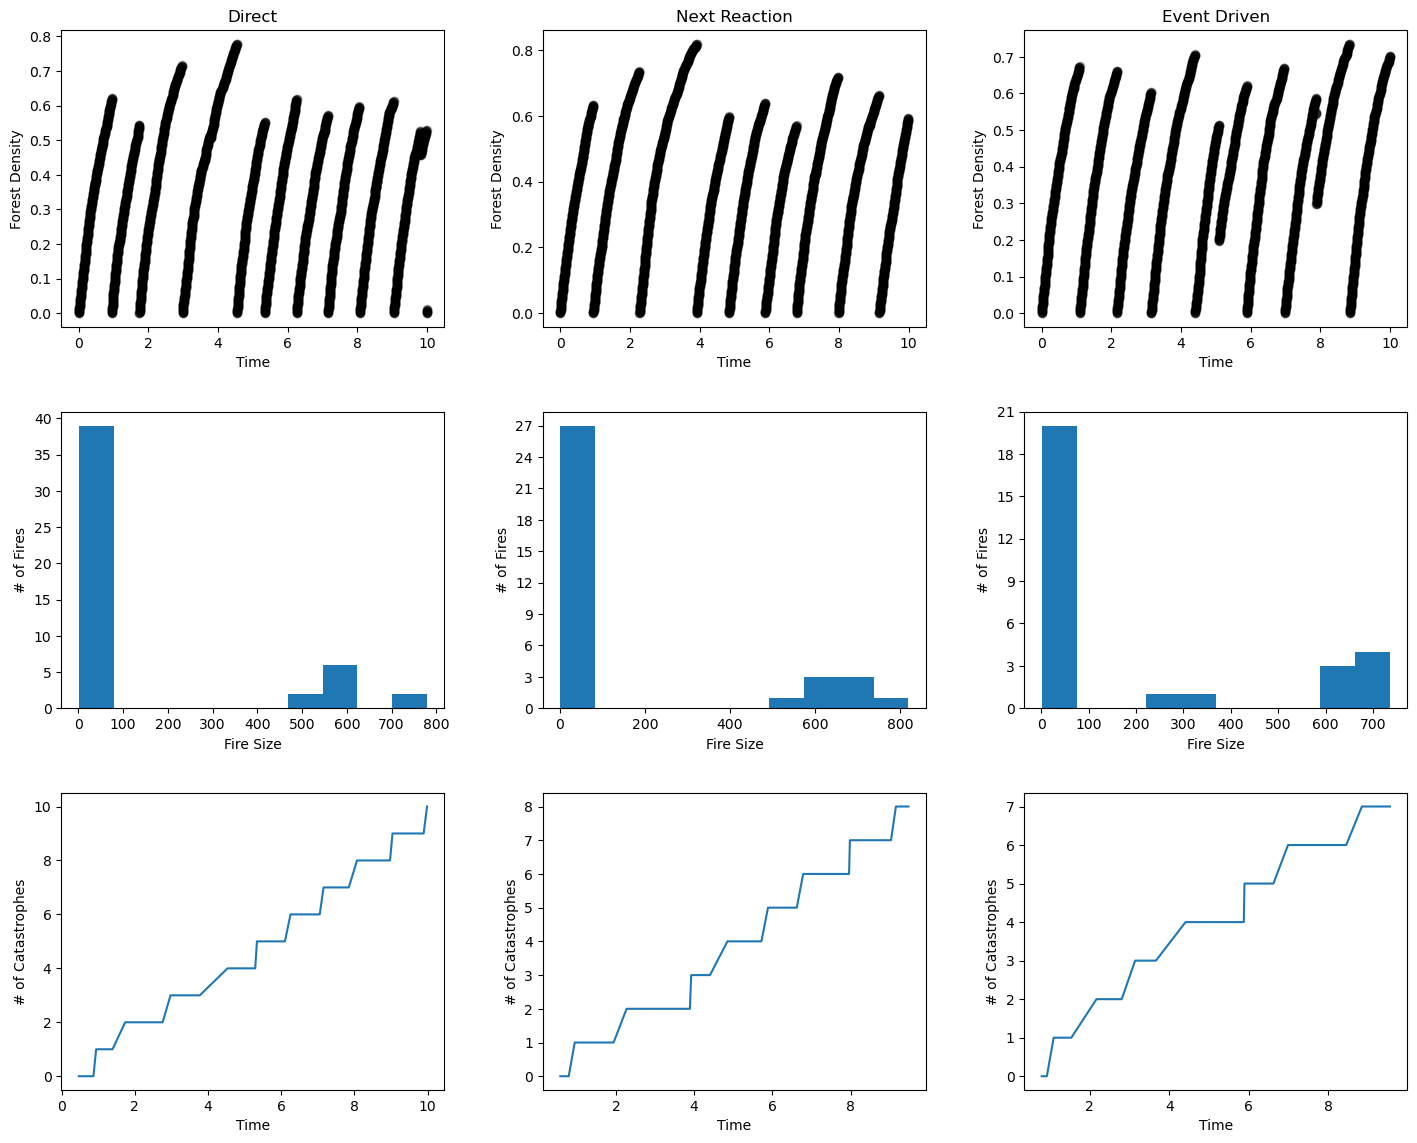

In [144]:
times, density, fire_sizes, fire_times, catastrophes, runtime = run_direct_simulation(
    1000, 10, growth_rate, lightning_rate
)
nr_times, nr_density, nr_fire_sizes, nr_fire_times, nr_catastrophes, nr_runtime = run_next_reaction_simulation(
    1000, 10, growth_rate, lightning_rate
)
ed_times, ed_density, ed_fire_sizes, ed_fire_times, ed_catastrophes, ed_runtime = run_event_driven_simulation(
    1000, 10, growth_rate, lightning_rate
)

print(f"Direct: {runtime:.2f}s | Next Reaction: {nr_runtime:.2f}s | Event Driven: {ed_runtime:.2f}s")

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
fig.tight_layout(pad=4.0)

sims = [
    ("Direct", times, density, fire_sizes, fire_times, catastrophes),
    ("Next Reaction", nr_times, nr_density, nr_fire_sizes, nr_fire_times, nr_catastrophes),
    ("Event Driven", ed_times, ed_density, ed_fire_sizes, ed_fire_times, ed_catastrophes),
]

for col, (label, t, dens, fsizes, ftimes, cats) in enumerate(sims):
    axes[0][col].plot(t, dens, marker="o", ls='', color='black', alpha=0.25)
    axes[0][col].set_title(label)
    axes[0][col].set_xlabel('Time')
    axes[0][col].set_ylabel('Forest Density')

    axes[1][col].hist(fsizes)
    axes[1][col].yaxis.set_major_locator(plt.MaxNLocator(integer=True))
    axes[1][col].set_xlabel('Fire Size')
    axes[1][col].set_ylabel('# of Fires')

    axes[2][col].plot(ftimes, np.cumsum(cats))
    axes[2][col].yaxis.set_major_locator(plt.MaxNLocator(integer=True))
    axes[2][col].set_xlabel('Time')
    axes[2][col].set_ylabel('# of Catastrophes')

plt.show()

## Vary $L$ and $T$ and detrmine which approach is faster

Direct L=10: 0.00s
Direct L=100: 0.07s
Direct L=1000: 7.90s
Next Reaction L=10: 0.00s
Next Reaction L=100: 0.02s
Next Reaction L=1000: 0.26s
Next Reaction L=10000: 4.70s
Next Reaction L=100000: 179.19s
Event Driven L=10: 0.00s
Event Driven L=100: 0.00s
Event Driven L=1000: 0.07s
Event Driven L=10000: 1.47s
Event Driven L=100000: 56.84s


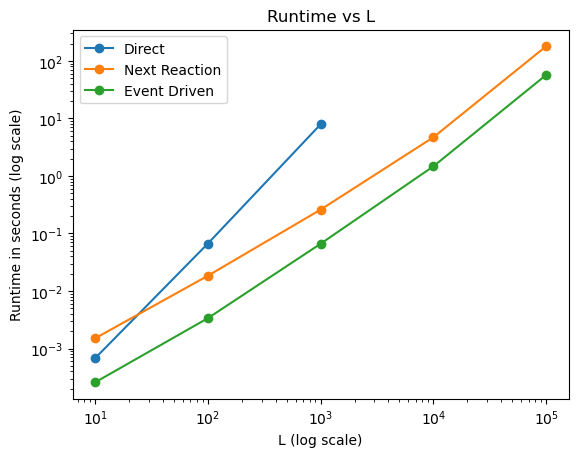


Algo                  L Runtime(s)  Mean Density  # Fires  Mean Fire Sz  # Cats
--------------------------------------------------------------------------------
Direct               10       0.00         0.432        2          9.50       2
Direct              100       0.07         0.412        8         53.12       5
Direct             1000       7.90         0.317       44        129.73       9
Next Reaction        10       0.00         0.479        3          4.33       1
Next Reaction       100       0.02         0.443        8         44.88       4
Next Reaction      1000       0.26         0.358       40        130.90       7
Next Reaction     10000       4.70         0.298      368        179.48       8
Next Reaction    100000     179.19         0.309     3320        194.04       0
Event Driven         10       0.00         0.478        2         10.00       2
Event Driven        100       0.00         0.436        6         45.83       3
Event Driven       1000       0.07    

In [145]:
L_values_direct = [10, 10**2, 10**3]
L_values_fast = [10, 10**2, 10**3, 10**4, 10**5]
T = 10

direct_runtimes = []
nr_runtimes = []
ed_runtimes = []

results_L = []

for L in L_values_direct:
    _, density, fire_sizes, _, catastrophes, rt = run_direct_simulation(L, T, growth_rate, lightning_rate)
    direct_runtimes.append(rt)
    results_L.append({
        'algo': 'Direct', 'L': L, 'T': T,
        'runtime': rt,
        'mean_density': np.mean(density),
        'n_fires': len(fire_sizes),
        'mean_fire_size': np.mean(fire_sizes) if fire_sizes else 0,
        'n_catastrophes': sum(catastrophes),
    })
    print(f"Direct L={L}: {rt:.2f}s")

for L in L_values_fast:
    _, density, fire_sizes, _, catastrophes, rt = run_next_reaction_simulation(L, T, growth_rate, lightning_rate)
    nr_runtimes.append(rt)
    results_L.append({
        'algo': 'Next Reaction', 'L': L, 'T': T,
        'runtime': rt,
        'mean_density': np.mean(density),
        'n_fires': len(fire_sizes),
        'mean_fire_size': np.mean(fire_sizes) if fire_sizes else 0,
        'n_catastrophes': sum(catastrophes),
    })
    print(f"Next Reaction L={L}: {rt:.2f}s")

for L in L_values_fast:
    _, density, fire_sizes, _, catastrophes, rt = run_event_driven_simulation(L, T, growth_rate, lightning_rate)
    ed_runtimes.append(rt)
    results_L.append({
        'algo': 'Event Driven', 'L': L, 'T': T,
        'runtime': rt,
        'mean_density': np.mean(density),
        'n_fires': len(fire_sizes),
        'mean_fire_size': np.mean(fire_sizes) if fire_sizes else 0,
        'n_catastrophes': sum(catastrophes),
    })
    print(f"Event Driven L={L}: {rt:.2f}s")

# runtime plot
plt.plot(L_values_direct, direct_runtimes, marker='o', label='Direct')
plt.plot(L_values_fast, nr_runtimes, marker='o', label='Next Reaction')
plt.plot(L_values_fast, ed_runtimes, marker='o', label='Event Driven')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('L (log scale)')
plt.ylabel('Runtime in seconds (log scale)')
plt.title('Runtime vs L')
plt.legend()
plt.show()

# results table
print(f"\n{'Algo':<16} {'L':>6} {'Runtime(s)':>10} {'Mean Density':>13} {'# Fires':>8} {'Mean Fire Sz':>13} {'# Cats':>7}")
print("-" * 80)
for r in results_L:
    print(f"{r['algo']:<16} {r['L']:>6} {r['runtime']:>10.2f} {r['mean_density']:>13.3f} {r['n_fires']:>8} {r['mean_fire_size']:>13.2f} {r['n_catastrophes']:>7}")

Next Reaction T=10: 0.31s
Next Reaction T=100: 2.98s
Next Reaction T=1000: 27.59s
Next Reaction T=10000: 280.90s
Event Driven T=10: 0.06s
Event Driven T=100: 0.60s
Event Driven T=1000: 5.95s
Event Driven T=10000: 58.15s


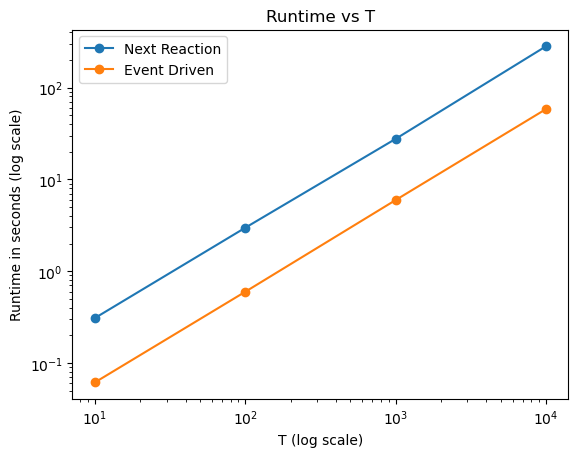


Algo                  T Runtime(s)  Mean Density  # Fires  Mean Fire Sz  # Cats
--------------------------------------------------------------------------------
Next Reaction        10       0.31         0.321       38        155.32       9
Next Reaction       100       2.98         0.340      428        138.14      85
Next Reaction      1000      27.59         0.339     4102        144.53     864
Next Reaction     10000     280.90         0.340    41062        144.47    8642
Event Driven         10       0.06         0.339       45        122.67       8
Event Driven        100       0.60         0.341      441        135.07      87
Event Driven       1000       5.95         0.341     4126        143.57     858
Event Driven      10000      58.15         0.341    40470        145.99    8608


In [146]:
T_values_fast = [10, 10**2, 10**3, 10**4]
L = 1000

nr_runtimes_T = []
ed_runtimes_T = []

# store summary stats per run
results = []

for T in T_values_fast:
    _, density, fire_sizes, _, catastrophes, rt = run_next_reaction_simulation(L, T, growth_rate, lightning_rate)
    nr_runtimes_T.append(rt)
    results.append({
        'algo': 'Next Reaction', 'T': T, 'L': L,
        'runtime': rt,
        'mean_density': np.mean(density),
        'n_fires': len(fire_sizes),
        'mean_fire_size': np.mean(fire_sizes) if fire_sizes else 0,
        'n_catastrophes': sum(catastrophes),
    })
    print(f"Next Reaction T={T}: {rt:.2f}s")

for T in T_values_fast:
    _, density, fire_sizes, _, catastrophes, rt = run_event_driven_simulation(L, T, growth_rate, lightning_rate)
    ed_runtimes_T.append(rt)
    results.append({
        'algo': 'Event Driven', 'T': T, 'L': L,
        'runtime': rt,
        'mean_density': np.mean(density),
        'n_fires': len(fire_sizes),
        'mean_fire_size': np.mean(fire_sizes) if fire_sizes else 0,
        'n_catastrophes': sum(catastrophes),
    })
    print(f"Event Driven T={T}: {rt:.2f}s")

# runtime plot
plt.plot(T_values_fast, nr_runtimes_T, marker='o', label='Next Reaction')
plt.plot(T_values_fast, ed_runtimes_T, marker='o', label='Event Driven')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('T (log scale)')
plt.ylabel('Runtime in seconds (log scale)')
plt.title('Runtime vs T')
plt.legend()
plt.show()

# results table
print(f"\n{'Algo':<16} {'T':>6} {'Runtime(s)':>10} {'Mean Density':>13} {'# Fires':>8} {'Mean Fire Sz':>13} {'# Cats':>7}")
print("-" * 80)
for r in results:
    print(f"{r['algo']:<16} {r['T']:>6} {r['runtime']:>10.2f} {r['mean_density']:>13.3f} {r['n_fires']:>8} {r['mean_fire_size']:>13.2f} {r['n_catastrophes']:>7}")